# FA - autosfa Dataset

In [1]:
#disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

In [2]:
# autosfa dataset
from scientisttools.datasets import autosfa
autosfa

,CYL,PUISS,LONG,LARG,POIDS,VMAX,RND1,RND2,RND3,RND4,RND5,RND6
Modele,,,,,,,,,,,,
Alfasud TI,1350,79,393,161,870,165,1.029,0.109,0.267,-0.949,0.053,-1.144
Audi 100,1588,85,468,177,1110,160,0.379,0.367,-1.054,0.106,1.316,1.632
Simca 1300,1294,68,424,168,1050,152,-0.346,0.737,-0.056,-0.430,0.274,1.044
Citroen GS Club,1222,59,412,161,930,151,0.849,0.494,-0.320,0.729,0.637,0.793
Fiat 132,1585,98,439,164,1105,165,-1.425,-0.210,0.535,-0.200,-1.983,0.832
Lancia Beta,1297,82,429,169,1080,160,0.890,0.071,-1.308,-0.971,-0.131,-1.134
Peugeot 504,1796,79,449,169,1160,154,-0.860,-0.001,-0.315,-1.329,-0.605,1.299
Renault 16 TL,1565,55,424,163,1010,140,2.379,-1.367,-0.633,-1.448,0.609,-0.175
Renault 30,2664,128,452,173,1320,180,-0.578,0.705,-1.304,2.124,-1.132,-2.091


## Instanciation and training

In [3]:
# Instanciation
from scientisttools import FA
clf = FA(ncp=2,max_iter=1)

### `fit` function

In [4]:
# fit function
clf.fit(autosfa)

maximum iteration exceeded


,max_iter,1
,method,'principal'
,scale_unit,True
,ncp,2
,row_w,None
,col_w,None
,ind_sup,None
,sup_var,None
,min_error,0.001
,warn_message,True
Name,Type,Value


### `fit_transform` function

In [5]:
# fit_transform function - individuals coordinates
ind_coord = clf.fit_transform(autosfa)
ind_coord

maximum iteration exceeded


,Dim1,Dim2
Alfasud TI,-0.986199,-1.119263
Audi 100,0.523302,2.582756
Simca 1300,-0.472979,0.182853
Citroen GS Club,-1.081071,-0.098957
Fiat 132,0.368924,-0.960006
Lancia Beta,-0.198631,0.755777
Peugeot 504,0.183672,0.602165
Renault 16 TL,-1.270892,1.110566
Renault 30,2.096801,-0.904822
Toyota Corolla,-1.787926,-0.814933


### `transform` function

In [6]:
# transform function - coordinates of new data
ind_coord = clf.transform(clf.call_.X)
ind_coord

,Dim1,Dim2
Alfasud TI,-0.986199,-1.119263
Audi 100,0.523302,2.582756
Simca 1300,-0.472979,0.182853
Citroen GS Club,-1.081071,-0.098957
Fiat 132,0.368924,-0.960006
Lancia Beta,-0.198631,0.755777
Peugeot 504,0.183672,0.602165
Renault 16 TL,-1.270892,1.110566
Renault 30,2.096801,-0.904822
Toyota Corolla,-1.787926,-0.814933


## Eigenvalues

In [7]:
from scientisttools import get_eig, fviz_screeplot
eig = get_eig(clf)
eig

,Eigenvalue,Difference,Proportion (%),Cumulative (%)
Dim1,5.229521,4.218050,59.133515,59.133515
Dim2,1.011471,0.035886,11.437345,70.570860
Dim3,0.975585,0.252347,11.031560,81.602419
Dim4,0.723238,0.184633,8.178113,89.780532
Dim5,0.538606,0.275195,6.090355,95.870887
Dim6,0.263410,0.167558,2.978545,98.849432
Dim7,0.095852,0.089953,1.083860,99.933292
Dim8,0.005899,NaN,0.066708,100.000000


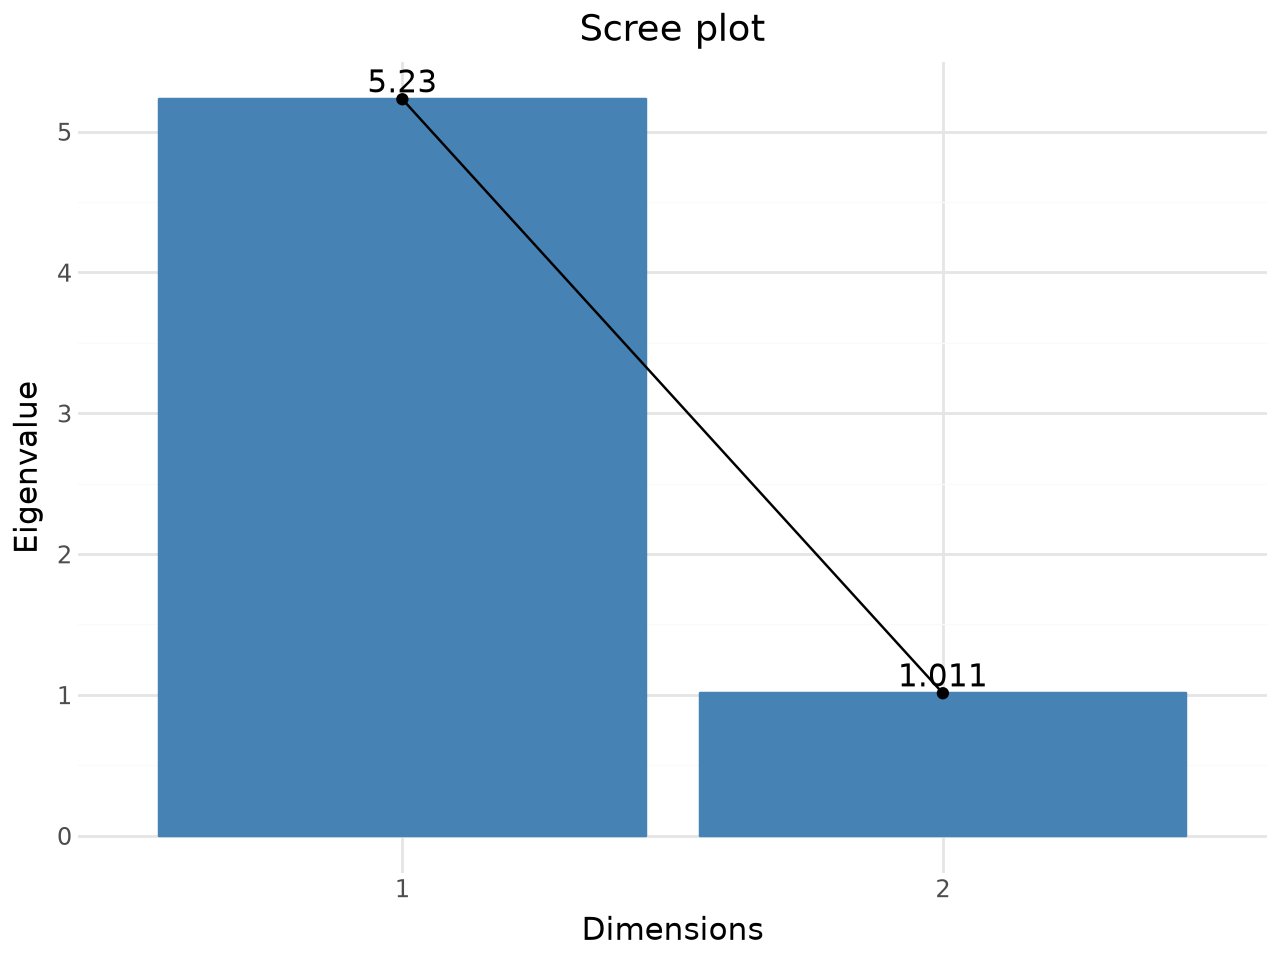

None


In [8]:
# screeplot
p = fviz_screeplot(
    obj = clf,
    choice = "eigenvalue",
    show_labels = True
)
print(p.show())

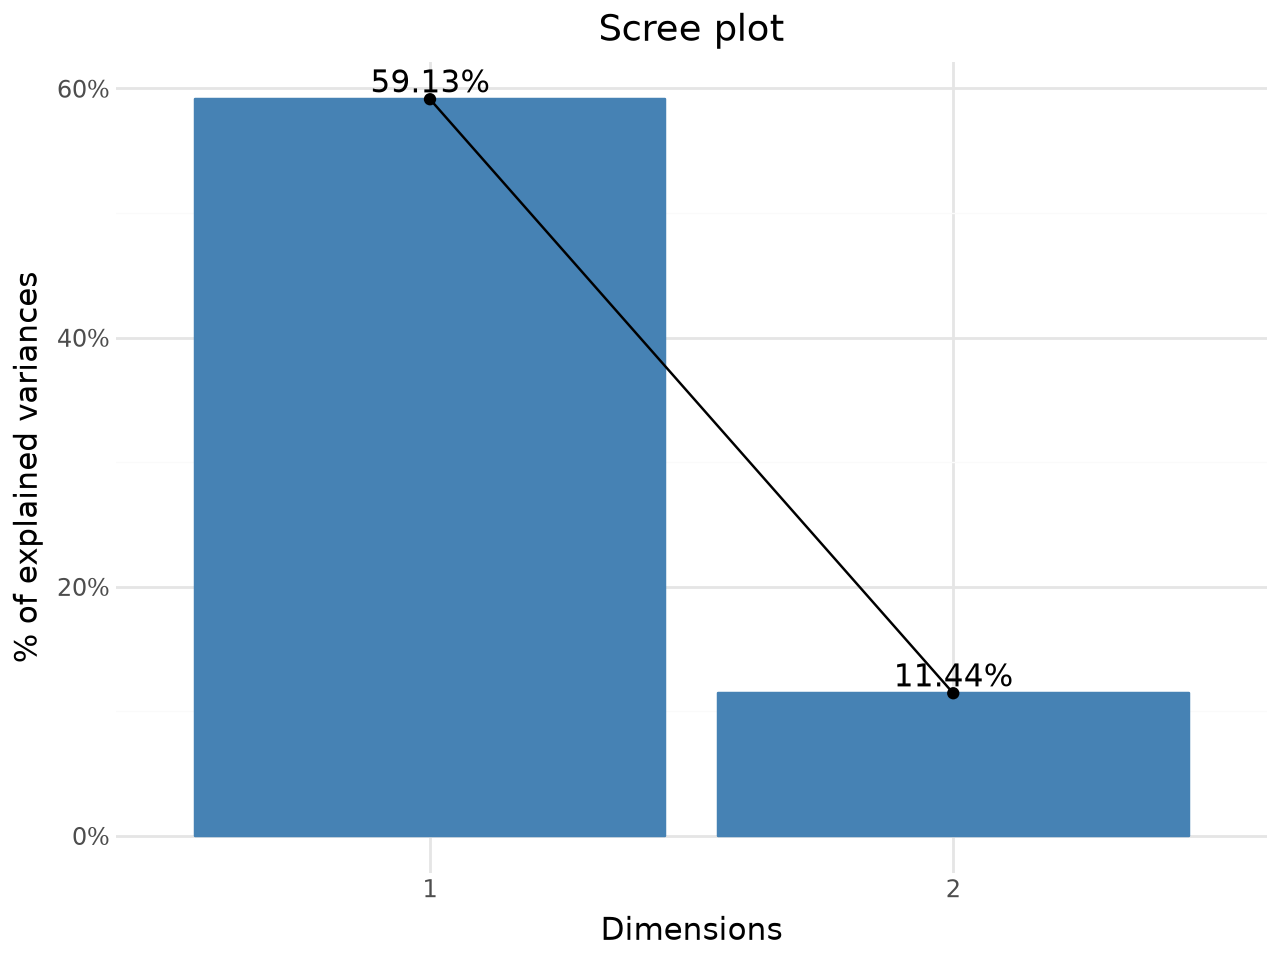

None


In [9]:
# proportion of variance
p = fviz_screeplot(
    obj = clf,
    choice = "proportion",
    show_labels = True
)
print(p.show())

## Individuals informations

In [10]:
from scientisttools import get_fa
ind = get_fa(clf,"ind")
ind._fields

('coord',)

### Individus coordinates

In [11]:
# individuals coordinates
ind.coord

,Dim1,Dim2
Alfasud TI,-0.986199,-1.119263
Audi 100,0.523302,2.582756
Simca 1300,-0.472979,0.182853
Citroen GS Club,-1.081071,-0.098957
Fiat 132,0.368924,-0.960006
Lancia Beta,-0.198631,0.755777
Peugeot 504,0.183672,0.602165
Renault 16 TL,-1.270892,1.110566
Renault 30,2.096801,-0.904822
Toyota Corolla,-1.787926,-0.814933


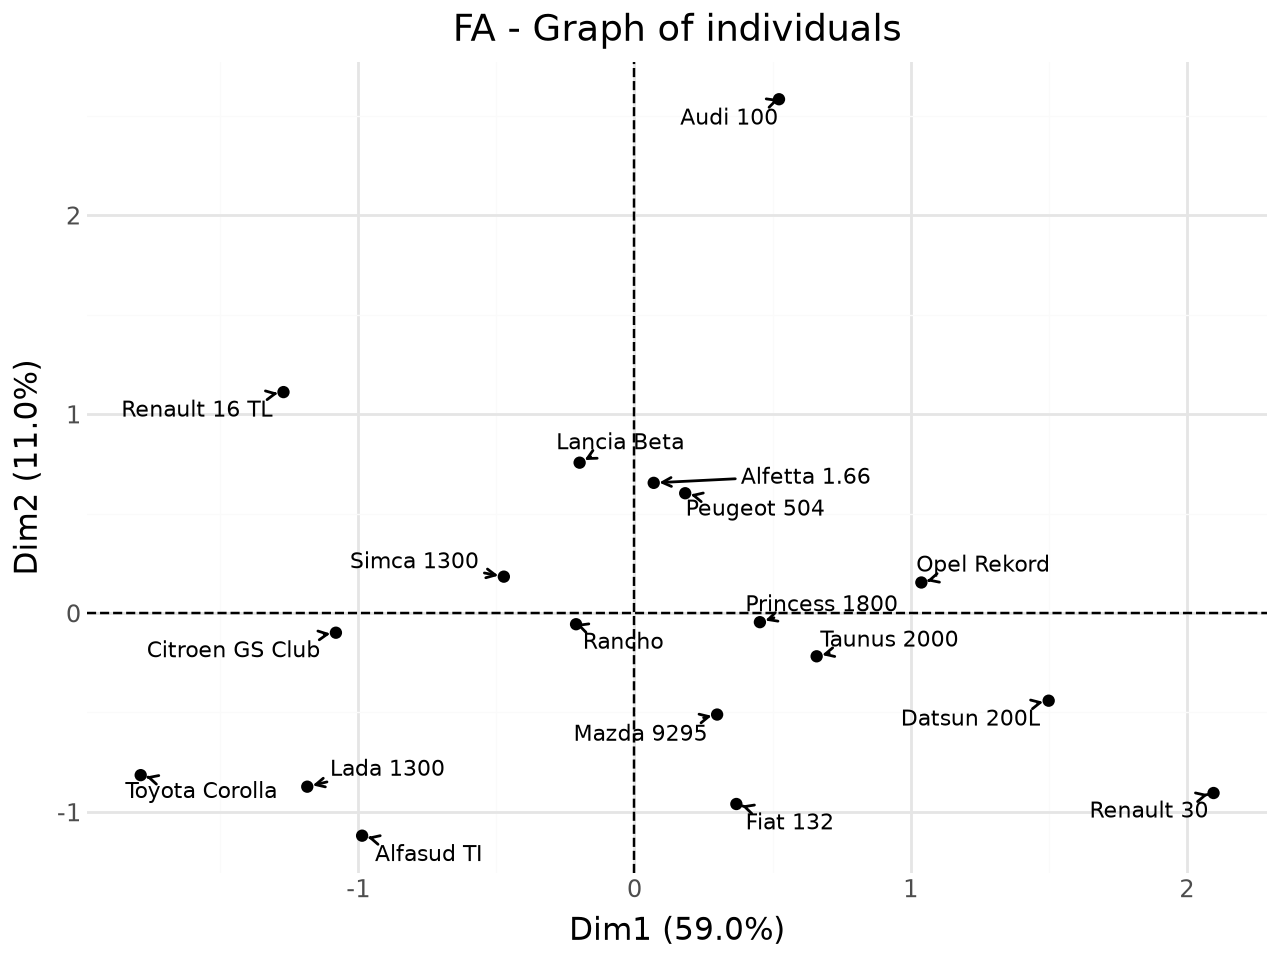

None


In [12]:
# individuals points
from scientisttools import fviz_fa
p = fviz_fa(
    obj = clf,
    choice = "ind",
    repel = True
)
print(p.show())

## Variables informations

In [13]:
# variables informations
quanti_var = get_fa(clf,"var")
quanti_var._fields

('coord', 'contrib', 'infos')

### Variables coordinates

In [14]:
# variables coordinates (=loadings)
quanti_var.coord

,Dim1,Dim2
CYL,0.874463,-0.084990
PUISS,0.893121,-0.117049
LONG,0.850778,0.367295
LARG,0.768420,0.423811
POIDS,0.894371,0.094914
VMAX,0.749973,-0.058408
RND1,-0.414234,0.231072
RND2,0.391899,-0.284307
RND3,-0.046057,-0.417174
RND4,0.524426,-0.181777


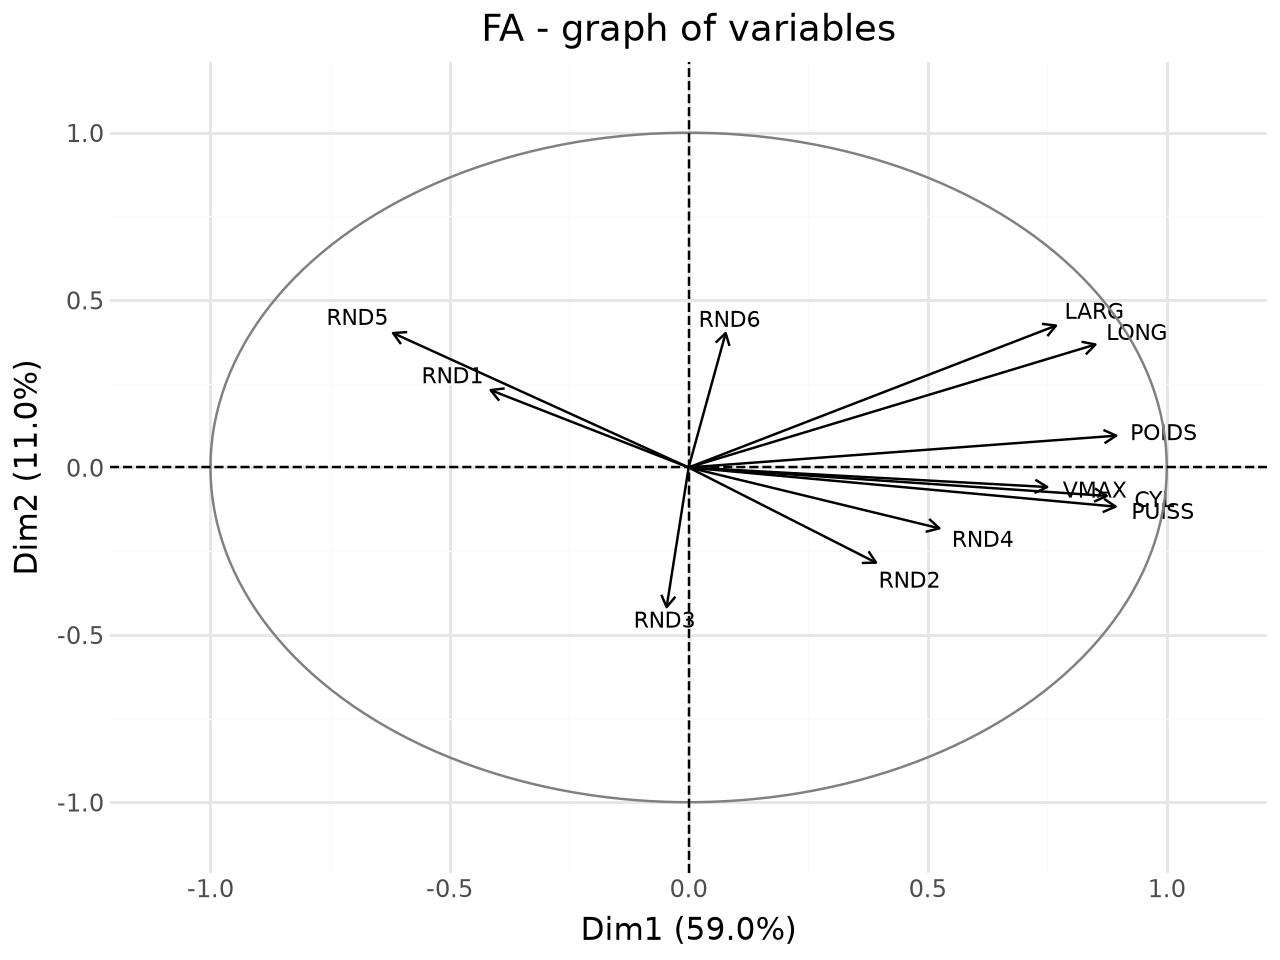

None


In [15]:
# correlation circle
p = fviz_fa(
    obj = clf,
    choice = "var",
    repel = True
)
print(p.show())

### Variables contributions

In [16]:
# variables contributions
quanti_var.contrib

,Dim1,Dim2
CYL,4.591390,6.407311
PUISS,18.757510,6.972512
LONG,22.163003,52.653268
LARG,4.781047,3.445412
POIDS,27.129689,0.164904
VMAX,17.003294,2.257864
RND1,0.588602,1.593921
RND2,1.379004,2.086494
RND3,0.356845,4.600698
RND4,2.180450,2.229176


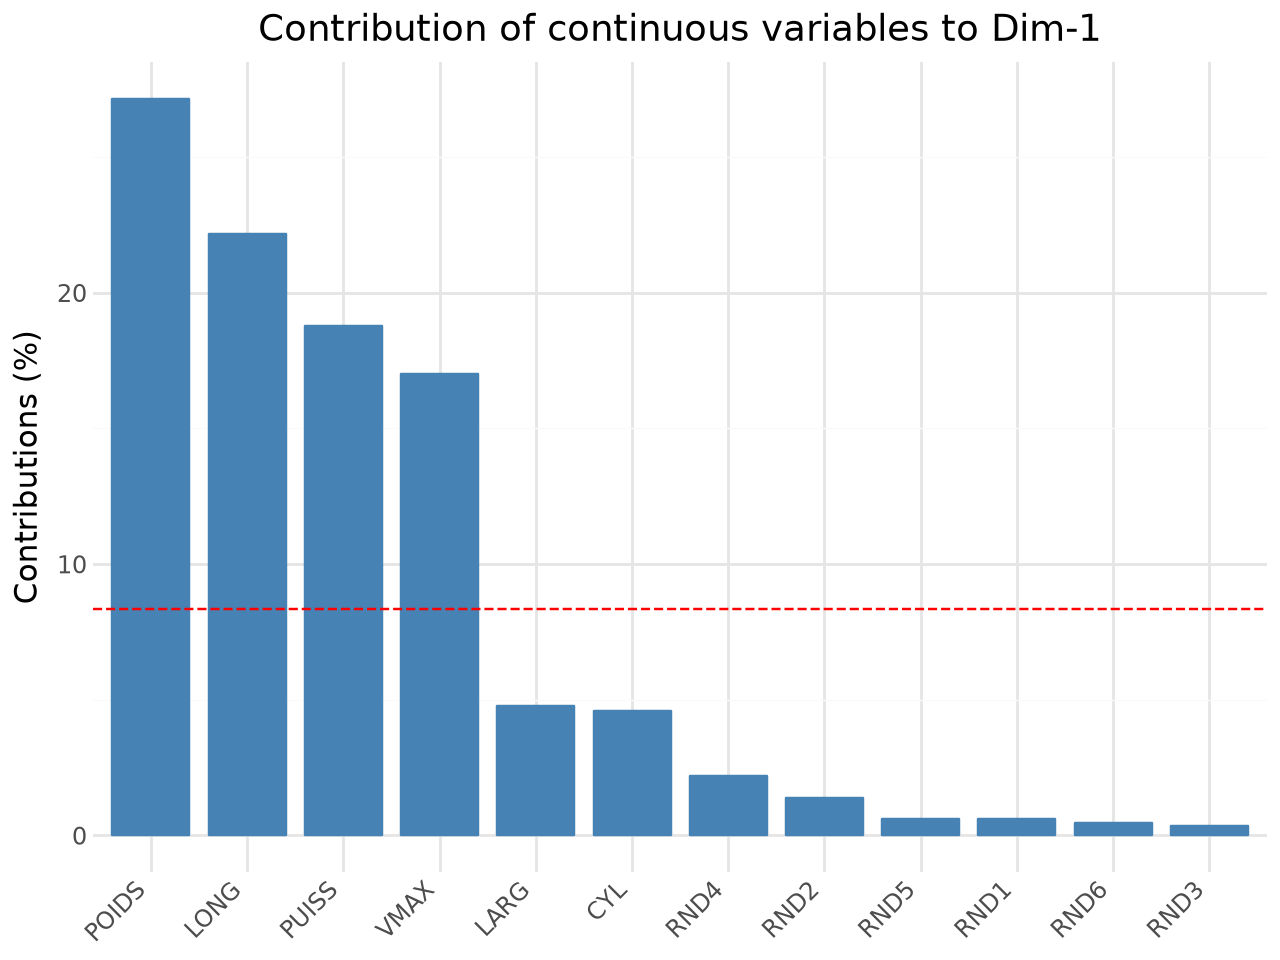

None


In [17]:
# contribution of continuous variables to Dim-1
from scientisttools import fviz_contrib
p = fviz_contrib(clf,"quanti_var")
print(p.show())

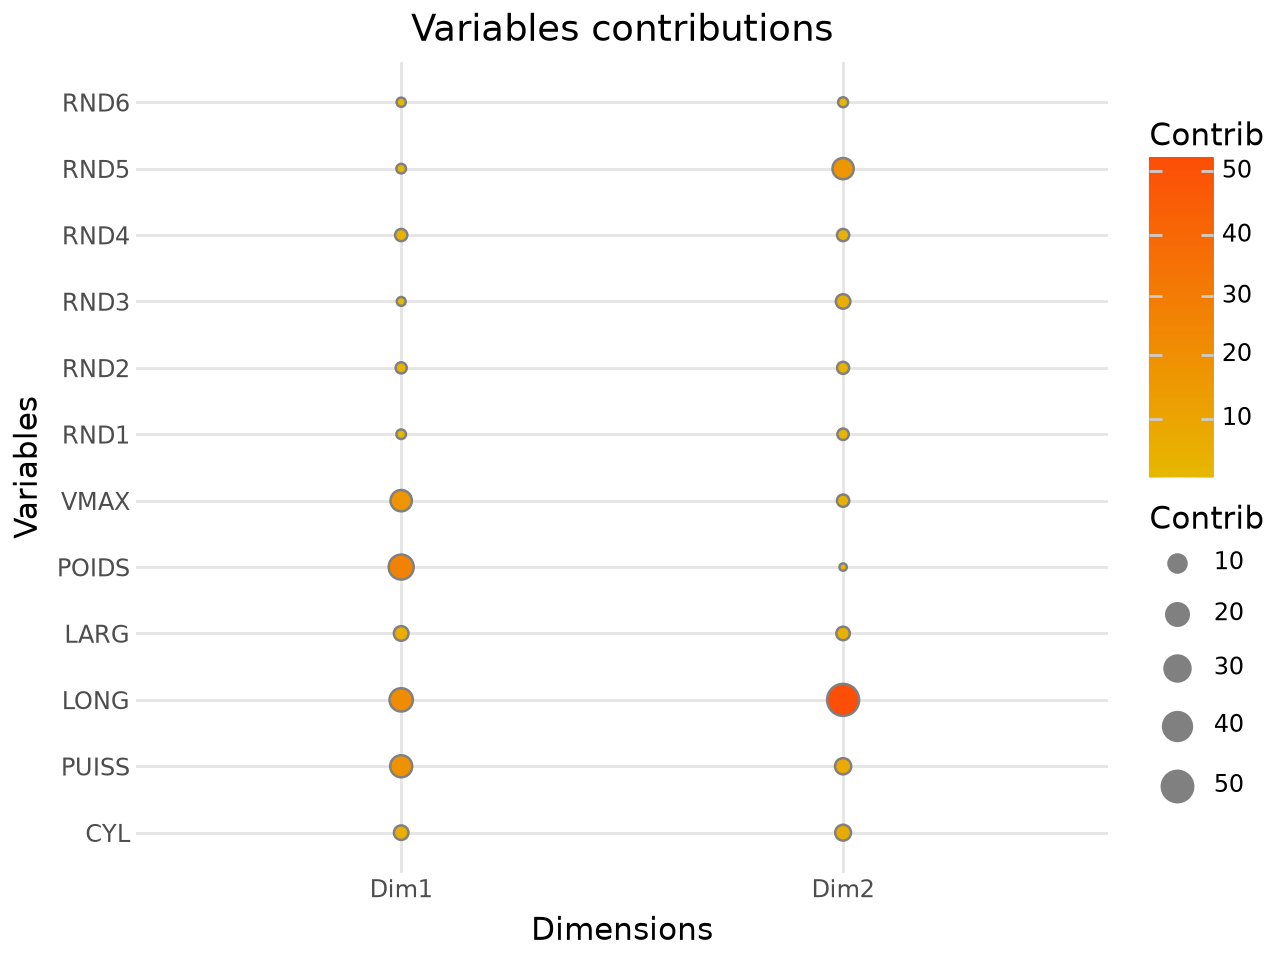

None


In [18]:
# variables contributions
from scientisttools import fviz_corrplot
p = fviz_corrplot(
    X = clf.quanti_var_.contrib,
    title="Variables contributions",
    legend_title="Contrib"
)
print(p.show())

### Variables additionals informations

In [19]:
# variables additionals informations
quanti_var.infos

,Weight,Prior,Final
CYL,1.0,0.843053,0.771910
PUISS,1.0,0.922937,0.811365
LONG,1.0,0.925902,0.858729
LARG,1.0,0.879876,0.770085
POIDS,1.0,0.923971,0.808908
VMAX,1.0,0.882288,0.565872
RND1,1.0,0.336690,0.224983
RND2,1.0,0.394369,0.234415
RND3,1.0,0.450844,0.176156
RND4,1.0,0.610068,0.308066


## Biplot

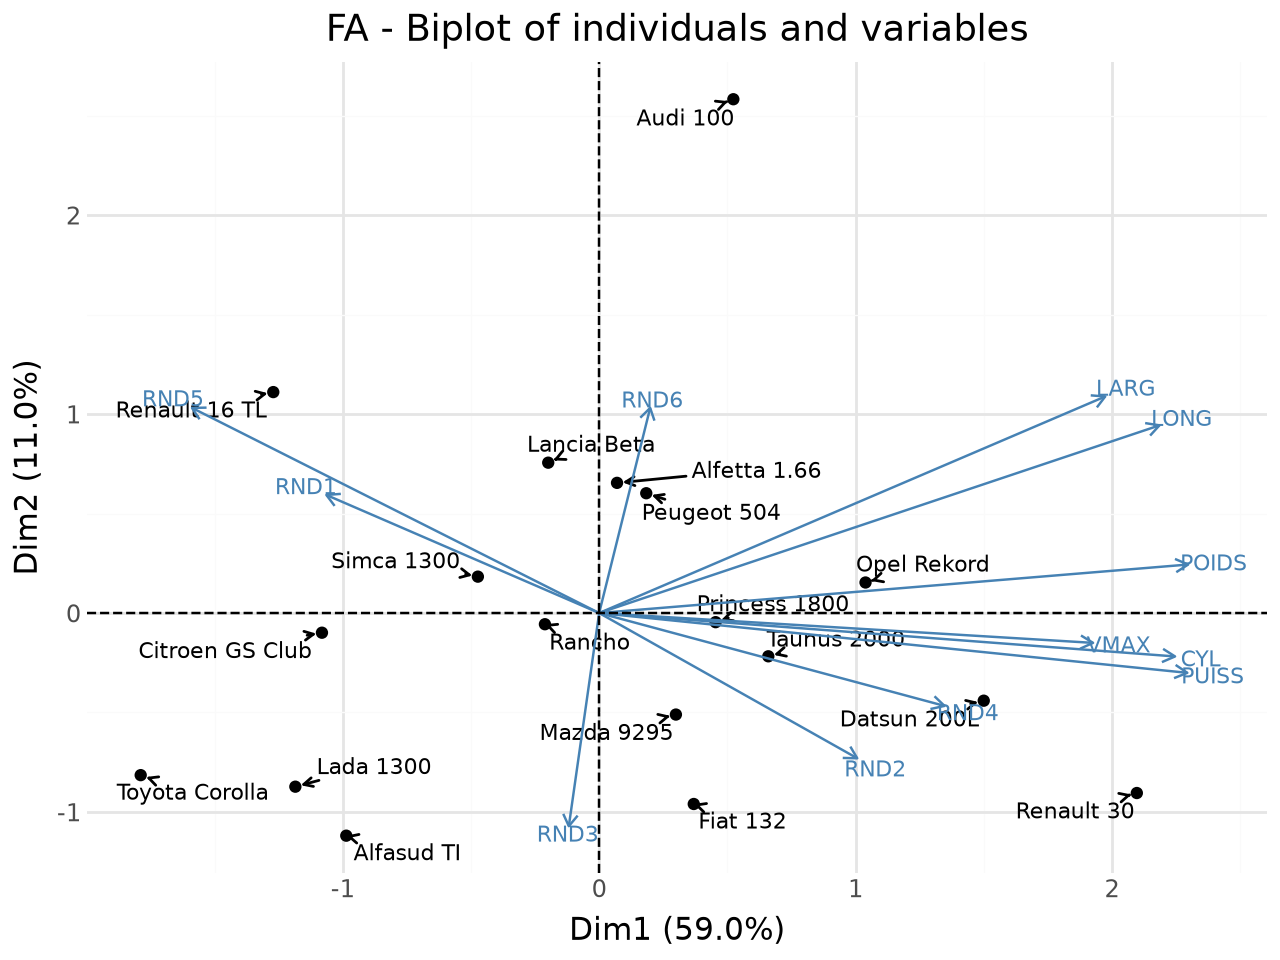

None


In [20]:
# biplot
p = fviz_fa(
    obj = clf,
    choice = "biplot",
    repel_ind = True,
    repel_var = True
)
print(p.show())

## Others elements

### Summary

In [21]:
# summary
from scientisttools import summary
summary(clf)

                     Factor Analysis - Results                     

Importance of components:
      Eigenvalue  Difference  Proportion (%)  Cumulative (%)
Dim1      5.2295      4.2180         59.1335         59.1335
Dim2      1.0115      0.0359         11.4373         70.5709

Individuals (the 10 first):
                   Dim1    Dim2
Alfasud TI      -0.9862 -1.1193
Audi 100         0.5233  2.5828
Simca 1300      -0.4730  0.1829
Citroen GS Club -1.0811 -0.0990
Fiat 132         0.3689 -0.9600
Lancia Beta     -0.1986  0.7558
Peugeot 504      0.1837  0.6022
Renault 16 TL   -1.2709  1.1106
Renault 30       2.0968 -0.9048
Toyota Corolla  -1.7879 -0.8149

Continuous (the 10 first):
         Dim1      ctr    Dim2      ctr
CYL    0.8745   4.5914 -0.0850   6.4073
PUISS  0.8931  18.7575 -0.1170   6.9725
LONG   0.8508  22.1630  0.3673  52.6533
LARG   0.7684   4.7810  0.4238   3.4454
POIDS  0.8944  27.1297  0.0949   0.1649
VMAX   0.7500  17.0033 -0.0584   2.2579
RND1  -0.4142   0.5886  0.2311   